# Customer Churn Prediction

**Problem Statement:**

In the telecom industry, customers are able to choose from a pool of companies to cater their needs regarding communication and internet. Customers are very critical about the kind of services they receive and judge the enitre company based on a single experience! These communication services have become so recurrent and inseparable from the daily routine that a 30 minute maintenance break kicks in anxiety in the users highlighting our taken-for-granted attitude towards these services! Coupled with high customer acquisation costs, churn analysis becomes very pivotal! Churn rate is a metric that describes the number of customers that cancelled or did not renew their subscription with the company. Thus, higher the churn rate, more customers stop buying from your business, directly affecting the revenue! Hence, based on the insights gained from the churn analysis, companies can build strategies, target segments, improve the quality of the services being provided to improve the customer experience, thus cultivating trust with the customers. That is why building predictive models and creating reports of churn analysis becomes key that paves the way for growth!

**Aim:**
- To classify the potential churn customers based on numerical and categorical features.
- It is a binary classification problem.

**Dataset attributes:**
- `customerID`: Customer ID
- `gender` : Whether the customer is a male or a female
- `SeniorCitizen`: Whether the customer is a senior citizen or not (1, 0)
- `Partner`: Whether the customer has a partner or not (Yes, No)
- `Dependents`: Whether the customer has dependents or not (Yes, No)
- `tenure`: Number of months the customer has stayed with the company
- `PhoneService`: Whether the customer has a phone service or not (Yes, No)
- `MultipleLines`: Whether the customer has multiple lines or not (Yes, No, No phone service)
- `InternetService`: Customer’s internet service provider (DSL, Fiber optic, No)
- `OnlineSecurity`: Whether the customer has online security or not (Yes, No, No internet service)
- `OnlineBackup`: Whether the customer has online backup or not (Yes, No, No internet service)
- `DeviceProtection`: Whether the customer has device protection or not (Yes, No, No internet service)
- `TechSupport`: Whether the customer has tech support or not (Yes, No, No internet service)
- `StreamingTV`: Whether the customer has streaming TV or not (Yes, No, No internet service)
- `StreamingMovies`: Whether the customer has streaming movies or not (Yes, No, No internet service)
- `Contract`: The contract term of the customer (Month-to-month, One year, Two year)
- `PaperlessBilling`: Whether the customer has paperless billing or not (Yes, No)
- `PaymentMethod`: The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))
- `MonthlyCharges`: The amount charged to the customer monthly
- `TotalCharges`: The total amount charged to the customer
- `Churn`: Whether the customer churned or not (Yes or No)

## Initial Data Exploration

In [1]:
# Import the Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
pd.options.display.float_format = '{:.2f}'.format
import warnings
warnings.filterwarnings('ignore')
import os

In [2]:
# Read the Dataset
raw = pd.read_csv("data/Teleco-Customer-Churn.csv")
raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
data=raw.copy(deep=True)

### Data Info

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
data.shape

(7043, 21)

### Checking Missing values

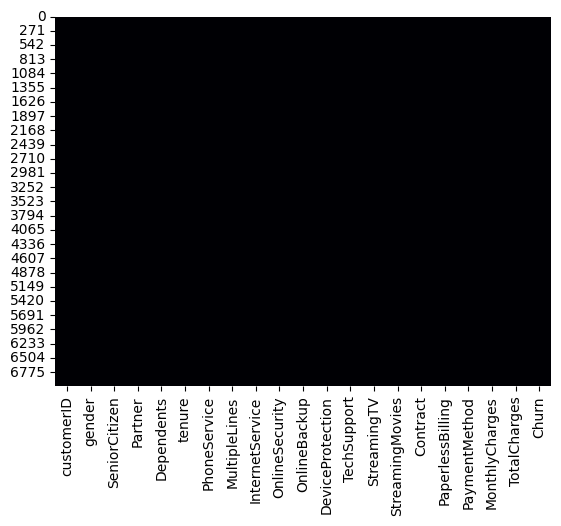

In [6]:
sns.heatmap(data.isnull(),cmap = 'magma',cbar = False);

No NULL values found in the dataset

#### Summary Stats

In [7]:
# Summary stats of the Dataset
data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.00,0.16,0.37,0.00,0.00,0.00,0.00,1.00
tenure,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.00,64.76,30.09,18.25,35.50,70.35,89.85,118.75


#### Initial data cleaning

- Dataset has many text features
- Target: Total charges is numerical but stored as object (string). Let's clean the TotalCharges column.

In [8]:
# Find the index positions where TotalCharges has empty spaces, clear them, and convert to float
l1 = [len(i.split()) for i in data['TotalCharges']]
l2 = [i for i in range(len(l1)) if l1[i] != 1] 
print('Index Positions with empty spaces : ',*l2)

# Clean the TotalCharges column
data['TotalCharges'] = data['TotalCharges'].replace(' ', np.nan)

# Convert to float
data['TotalCharges'] = data['TotalCharges'].astype(float)

Index Positions with empty spaces :  488 753 936 1082 1340 3331 3826 4380 5218 6670 6754


In [9]:
data['TotalCharges'].dtype

dtype('float64')

In [10]:
# Drop the customerID column as it is not useful for analysis
data.drop(columns = ['customerID'], inplace = True)

In [11]:
# Divide the dataset into numerical and categorical features
cat_features = []
num_features = []
for i in data.columns:
    if len(data[i].unique()) > 6:
        num_features.append(i)
    else:
        cat_features.append(i)

In [12]:
for cat_feature in cat_features:
    print(f"{cat_feature}: {data[cat_feature].unique()}")

gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [13]:
data[['MonthlyCharges', 'tenure', 'TotalCharges']].assign(total_charges=lambda x: x['MonthlyCharges'] * x['tenure']).head()

,MonthlyCharges,tenure,TotalCharges,total_charges
0,29.85,1,29.85,29.85
1,56.95,34,1889.50,1936.30
2,53.85,2,108.15,107.70
3,42.30,45,1840.75,1903.50
4,70.70,2,151.65,141.40


We can see there's a small miss calculation in total charges. Let's modify recreate the TotalCharges column by multipying the mothly charges by tenure.

In [14]:
# Recreate the TotalCharges column by multiplying the MonthlyCharges by tenure
data_copy = data.copy(deep = True)

data_copy['TotalCharges'] = data_copy['MonthlyCharges'] * data_copy['tenure']
data_copy[['MonthlyCharges', 'tenure', 'TotalCharges']].assign(total_charges=lambda x: x['MonthlyCharges'] * x['tenure']).head()

,MonthlyCharges,tenure,TotalCharges,total_charges
0,29.85,1,29.85,29.85
1,56.95,34,1936.30,1936.30
2,53.85,2,107.70,107.70
3,42.30,45,1903.50,1903.50
4,70.70,2,141.40,141.40


Now the TotalCharges is perfect.

**Encoding categorical features for EDA**

Let's encode these categorical features using LabelEncoder

In [15]:
# Encode the categorical features using LabelEncoder for analysis
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for cat_feature in cat_features:
    data_copy[cat_feature] = le.fit_transform(data_copy[cat_feature])
    print(f"{cat_feature}: {data_copy[cat_feature].unique()}")

gender: [0 1]
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
PhoneService: [0 1]
MultipleLines: [1 0 2]
InternetService: [0 1 2]
OnlineSecurity: [0 2 1]
OnlineBackup: [2 0 1]
DeviceProtection: [0 2 1]
TechSupport: [0 2 1]
StreamingTV: [0 2 1]
StreamingMovies: [0 2 1]
Contract: [0 1 2]
PaperlessBilling: [1 0]
PaymentMethod: [2 3 0 1]
Churn: [0 1]


We are creating a deep copy of the original data to make sure modifications in the original dataset will not be highlighted in this deep copy.

In [16]:
data_copy.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00
mean,0.50,0.16,0.48,0.30,32.37,0.90,0.94,0.87,0.79,0.91,0.90,0.80,0.99,0.99,0.69,0.59,1.57,64.76,2279.58,0.27
std,0.50,0.37,0.50,0.46,24.56,0.30,0.95,0.74,0.86,0.88,0.88,0.86,0.89,0.89,0.83,0.49,1.07,30.09,2264.73,0.44
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18.25,0.00,0.00
25%,0.00,0.00,0.00,0.00,9.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,35.50,394.00,0.00
50%,1.00,0.00,0.00,0.00,29.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,2.00,70.35,1393.60,0.00
75%,1.00,0.00,1.00,1.00,55.00,1.00,2.00,1.00,2.00,2.00,2.00,2.00,2.00,2.00,1.00,1.00,2.00,89.85,3786.10,1.00
max,1.00,1.00,1.00,1.00,72.00,1.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,1.00,3.00,118.75,8550.00,1.00


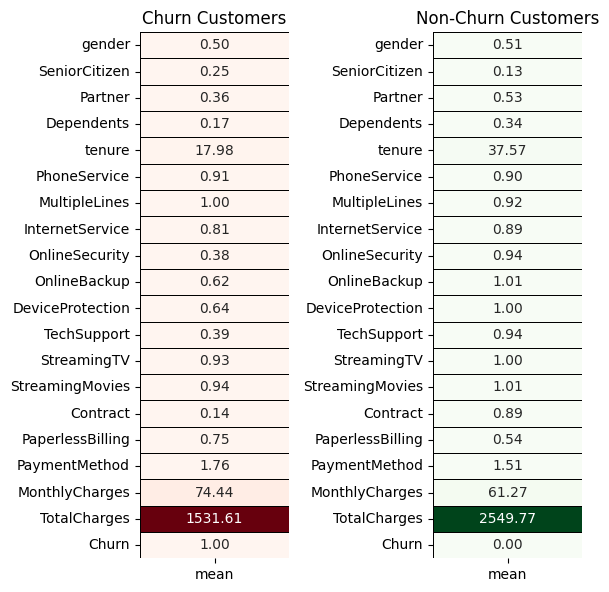

In [17]:
# Define the colors for the churn and non-churn classes
colors = ["#34954E", "#E64F35"]  # Green for non-churn, Red for churn

churn = data_copy[data_copy['Churn'] == 1].describe().T
not_churn = data_copy[data_copy['Churn'] == 0].describe().T

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6, 6))
plt.subplot(1, 2, 1)
sns.heatmap(churn[['mean']], annot=True, cmap='Reds', cbar=False, fmt=".2f", linecolor='black', linewidths=0.5)
plt.title('Churn Customers')
plt.subplot(1, 2, 2)
sns.heatmap(not_churn[['mean']], annot=True, cmap='Greens', cbar=False, fmt=".2f", linecolor='black', linewidths=0.5)
plt.title('Non-Churn Customers')

fig.tight_layout(pad = 1)

- Customers who churned had low average tenure of 17.98 months and paid less in total charges of $1531.8 compared to those who continued with average tenure of 37.57 and total charges of $2555.34.
- There is a smaller portion of churn customers with average contract (0.14) compared to non-churn customers (0.89).
- Non-churn customers show higher usage of services like OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport.
- PaperlessBilling is mostly prefered by Churn customers than Non-churn customers.
- Features like gender, phone service, multiple lines, internet service, streaming TV/movies, payment method, and monthly charges show less significant differences between churn and non-churn groups. 

## EDA

In [18]:
print('Categorical Features :',cat_features)
print('Numerical Features :', num_features)

Categorical Features : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Numerical Features : ['tenure', 'MonthlyCharges', 'TotalCharges']


### Target variable distribution

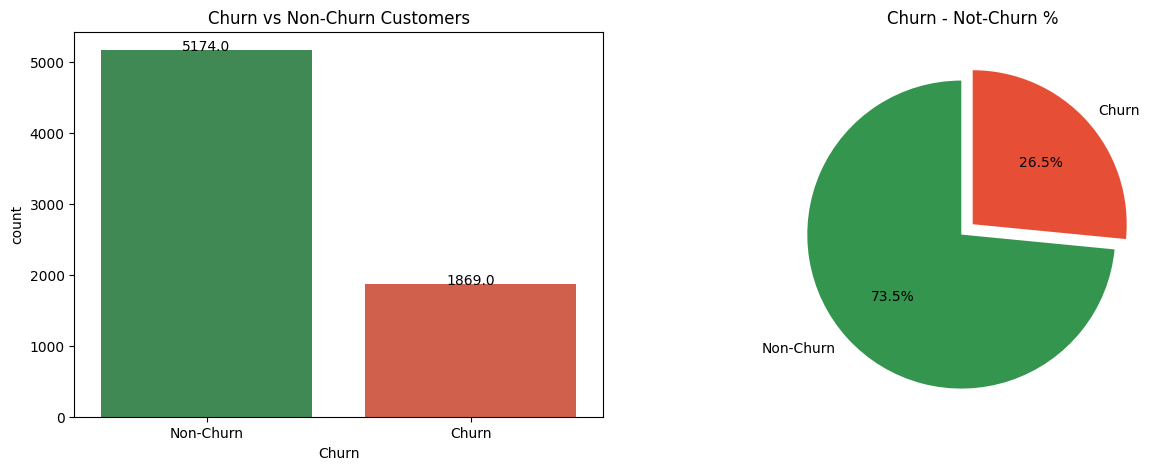

In [19]:
# Target variable visualization
churn_distribution = dict(data['Churn'].value_counts())
sum_churn = sum(churn_distribution.values())
churn_percentage = {k: v / sum_churn * 100 for k, v in churn_distribution.items()}

# Plot  a count plot for churn distribution and a pie chart for churn percentage
fig = plt.figure(figsize=(15, 5))
plt.subplot(1,2,1)
ax = sns.countplot(x='Churn', data=data, palette=colors)
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 2, rect.get_height(), horizontalalignment='center', fontsize = 10)
ax.set_xticklabels(['Non-Churn', 'Churn'])
plt.title('Churn vs Non-Churn Customers')

plt.subplot(1,2,2)
plt.pie(churn_percentage.values(), labels=['Non-Churn', 'Churn'], startangle=90, colors=colors, autopct = '%1.1f%%', explode=(0.1, 0))
plt.title('Churn - Not-Churn %')

plt.show()

- Total Non-churn customers are 5174 and 1860 churn customers.
- Proportion of Non-Churn customers (73.5%) is more than churn customers (26.5%).
- Dataset is unbalanced with a ratio of approximately 3:1 for Non-churn to churn.

### Categorical features vs target (Churn)

In [20]:
# Categorical features vs target variable
cat_features.remove('Churn')

In [21]:
# Define the categorical features and their respective groups
customer_demographics = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
services_signed_up = {
    'Phone Services': ['PhoneService', 'MultipleLines'],
    'Internet Services': ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport'],
    'Streaming Services': ['StreamingTV', 'StreamingMovies'],
}
payment_info = ['Contract', 'PaperlessBilling', 'PaymentMethod']

Categorical features have been divided into groups for comprehensive analysis.

#### Group 1: Customer Demographis vs target
- gender
- SeniorCitizen
- Partner
- Dependents

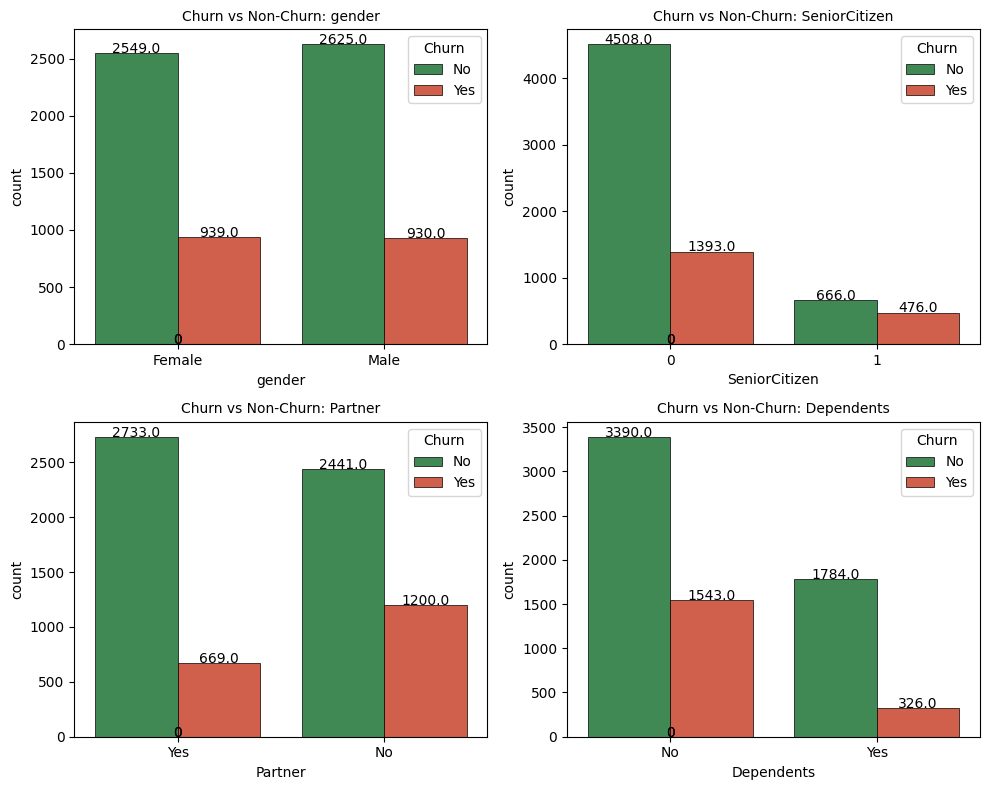

In [22]:
# Churn vs Non-Churn Customers for customer demographics
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axes = axes.flatten()
for i, feature in enumerate(customer_demographics):
    ax = axes[i]
    sns.countplot(x=feature, hue='Churn', palette=colors, data=data, edgecolor='black', linewidth=0.5, ax=ax)
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 2, p.get_height(),
                horizontalalignment='center', fontsize=10)
    ax.set_title(f'Churn vs Non-Churn: {feature}', fontsize=10)
plt.tight_layout()

- Churn rates are very similar for both Female and Male customers, indicating gender is not a significant predictor of churn.
- Senior citizens have a notably higher churn rate compared to non-senior citizens. A much larger percentage of senior citizens leave the service.
- Customers without a partner are more likely to churn than those with a partner.
- Customers without dependents are significantly more likely to churn than those with dependents.

#### Group 2: Services subscribed vs target

In [23]:
services_signed_up

{'Phone Services': ['PhoneService', 'MultipleLines'],
 'Internet Services': ['InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport'],
 'Streaming Services': ['StreamingTV', 'StreamingMovies']}

##### Phone Services

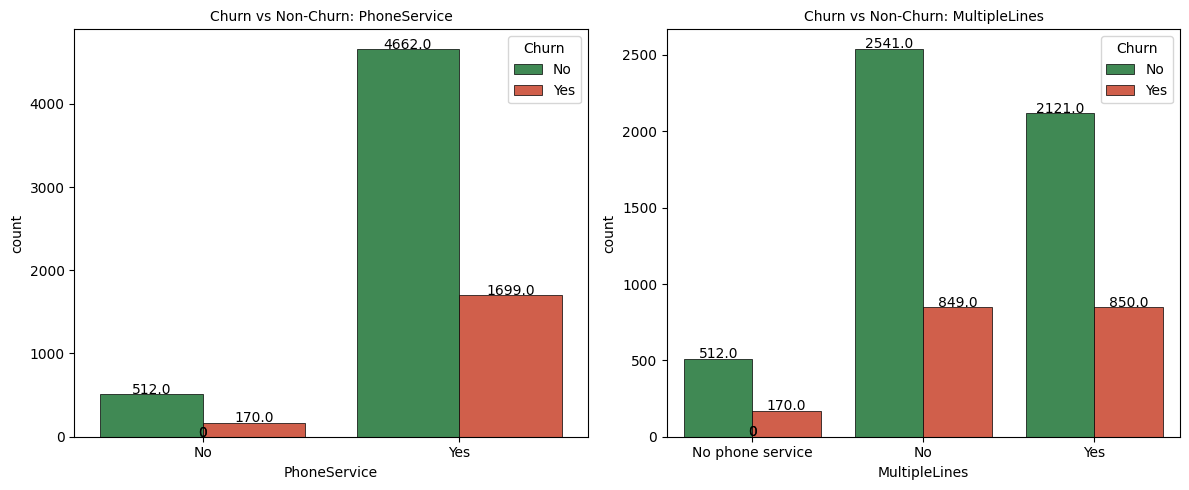

In [24]:
# Phone Services vs Churn
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
axes = axes.flatten()

for i, feature in enumerate(services_signed_up['Phone Services']):
    ax = axes[i]
    sns.countplot(x=feature, hue='Churn', palette=colors, data=data, edgecolor='black', linewidth=0.5, ax=ax)
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 2, p.get_height(),
                horizontalalignment='center', fontsize=10)
    ax.set_title(f'Churn vs Non-Churn: {feature}', fontsize=10)

plt.tight_layout()

- Despite the vast majority of customers having phone service, those who do not are significantly less likely to churn than those who do.
- Customers with multiple lines have a slightly higher churn rate than those with a single line or no phone service at all.

##### Internet Services

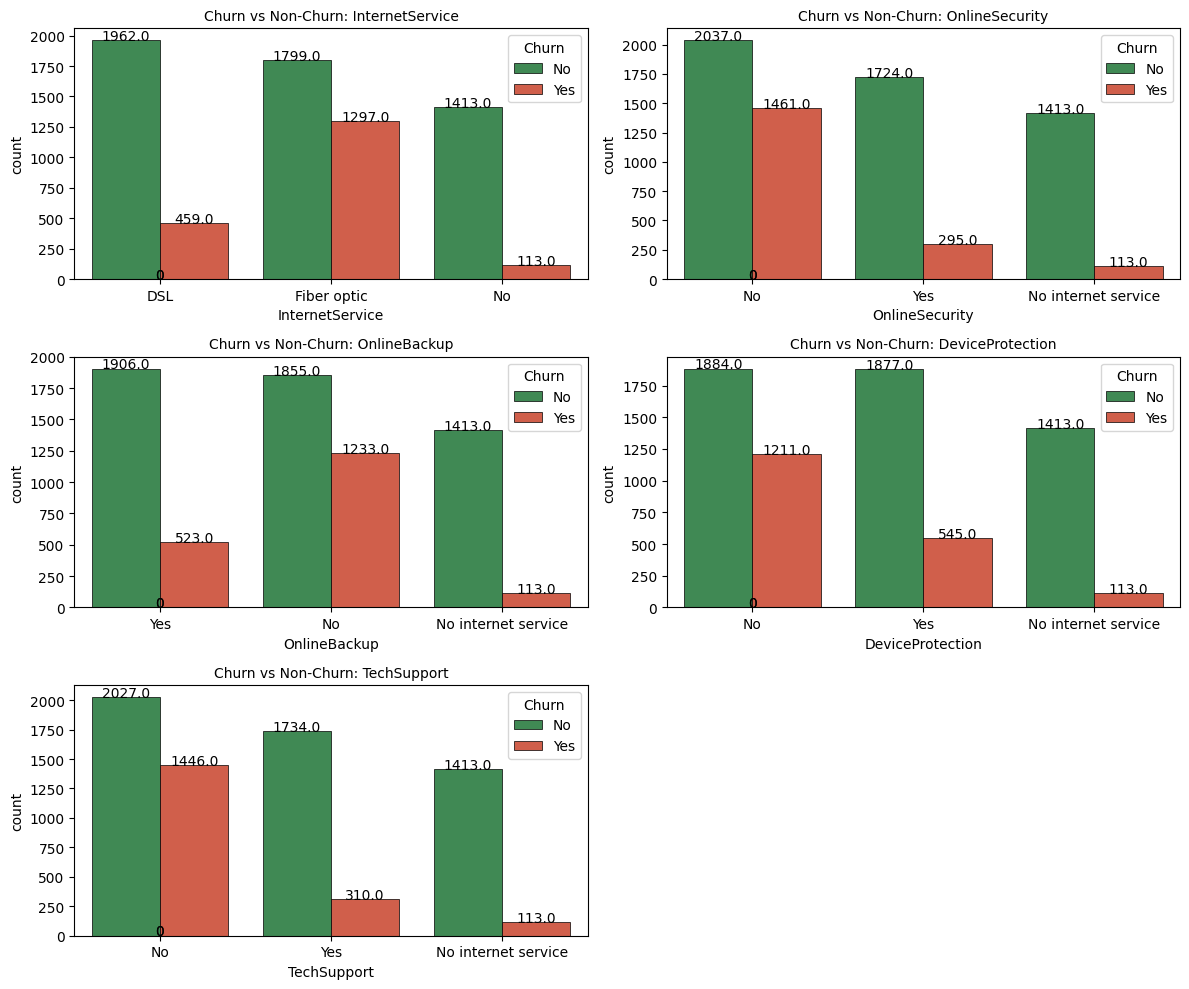

In [25]:
# Internet Services vs Churn
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
axes = axes.flatten()
for i, feature in enumerate(services_signed_up['Internet Services']):
    ax = axes[i]
    sns.countplot(x=feature, hue='Churn', palette=colors, data=data, edgecolor='black', linewidth=0.5, ax=ax)
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 2, p.get_height(),
                horizontalalignment='center', fontsize=10)
    ax.set_title(f'Churn vs Non-Churn: {feature}', fontsize=10)
# Remove any extra axes
for j in range(len(services_signed_up['Internet Services']), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()

- Customers who subscribe to fiber optic internet service churn more frequently, followed by those who have DSL and those who do not have internet service.
- Customers who enabled value-added services like OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport are less likely to churn compared to those who did not enalbe these services.

##### Streaming Services

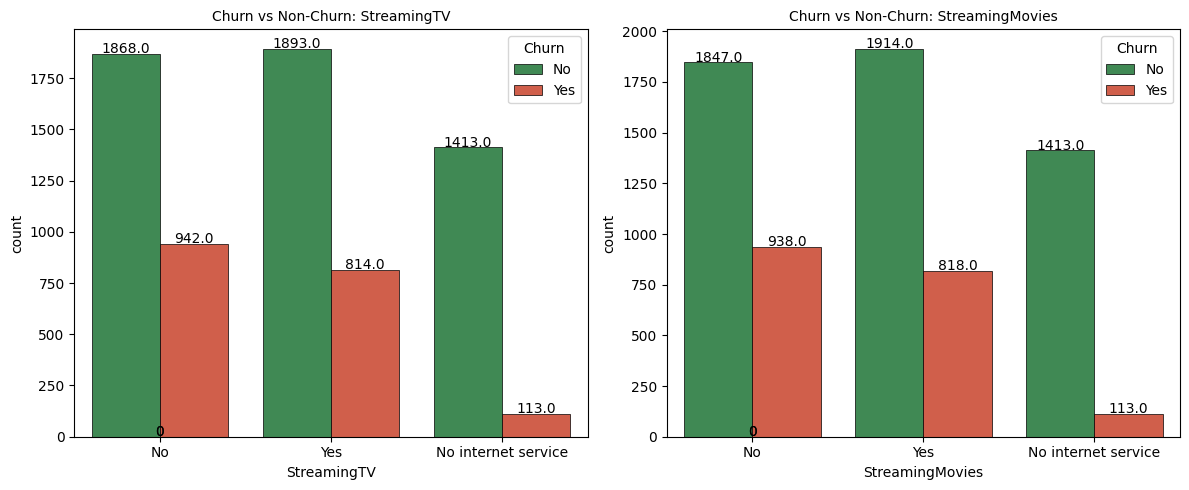

In [26]:
# Streaming Services vs Churn
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
axes = axes.flatten()

for i, feature in enumerate(services_signed_up['Streaming Services']):
    ax = axes[i]
    sns.countplot(x=feature, hue='Churn', palette=colors, data=data, edgecolor='black', linewidth=0.5, ax=ax)
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 2, p.get_height(),
                horizontalalignment='center', fontsize=10)
    ax.set_title(f'Churn vs Non-Churn: {feature}', fontsize=10)

plt.tight_layout()

- Customers who did not subscribed to Streaming TV have a slightly higher churn rate than those who do.
- Similarly, customers who do not subscribe to Streaming Movies also have a slightly higher churn rate than those who do.

#### Group 3: Payment Info vs target

In [27]:
payment_info

['Contract', 'PaperlessBilling', 'PaymentMethod']

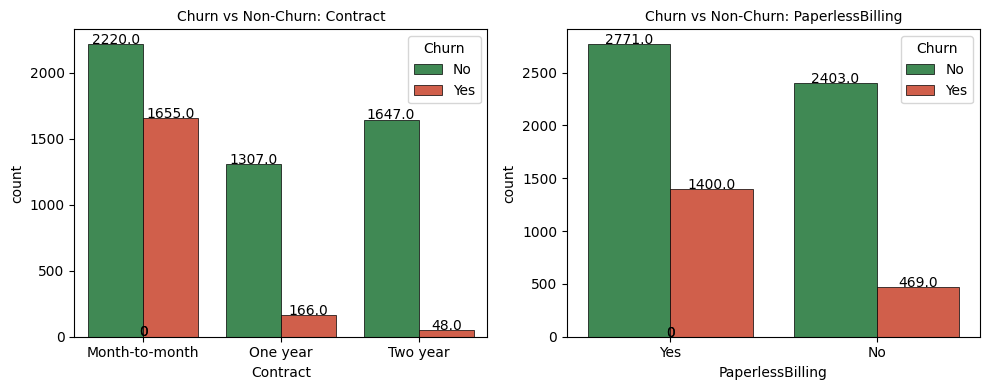

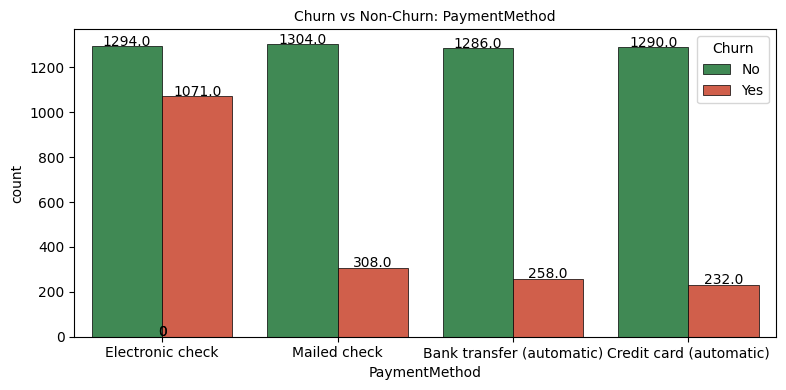

In [28]:
# Streaming Services vs Churn
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axes = axes.flatten()
for i, feature in enumerate(payment_info):
    if feature == 'PaymentMethod':
        # For PaymentMethod, we will plot it separately as it has more categories
        continue
    ax = axes[i]
    sns.countplot(x=feature, hue='Churn', palette=colors, data=data, edgecolor='black', linewidth=0.5, ax=ax)
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 2, p.get_height(),
                horizontalalignment='center', fontsize=10)
    ax.set_title(f'Churn vs Non-Churn: {feature}', fontsize=10)
plt.tight_layout()

# PaymentMethod vs Churn
plt.figure(figsize=(8, 4))
sns.countplot(x='PaymentMethod', hue='Churn', palette=colors, data=data, edgecolor='black', linewidth=0.5)
for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width()/2, p.get_height() + 2, p.get_height(),
             horizontalalignment='center', fontsize=10)
plt.title('Churn vs Non-Churn: PaymentMethod', fontsize=10)
plt.xticks(fontsize=10)
plt.tight_layout()

- Customers on month-to-month contracts have a significantly higher churn rate than those on one-year or two-year contracts. Customers with longer-term contracts are much more loyal.
- Customers who use paperless billing are more likely to churn than those who do not.
- Customers using Electronic Check as their payment method have a noticeably higher churn rate compared to those using Mailed Check, Bank Transfer, or Credit Card. Suggesting most of the customers are preferring Credit card (automatic) and Bank transfer (automatic) followed by Mailed check and Electronic check.

### Categorical features vs Churn (Yes)

##### Group 1: Customer Demographis who Churned

In [29]:
for service in customer_demographics:
    print(f"{service}: {data[service].unique()} -> {data_copy[service].unique()}")

gender: ['Female' 'Male'] -> [0 1]
SeniorCitizen: [0 1] -> [0 1]
Partner: ['Yes' 'No'] -> [1 0]
Dependents: ['No' 'Yes'] -> [0 1]


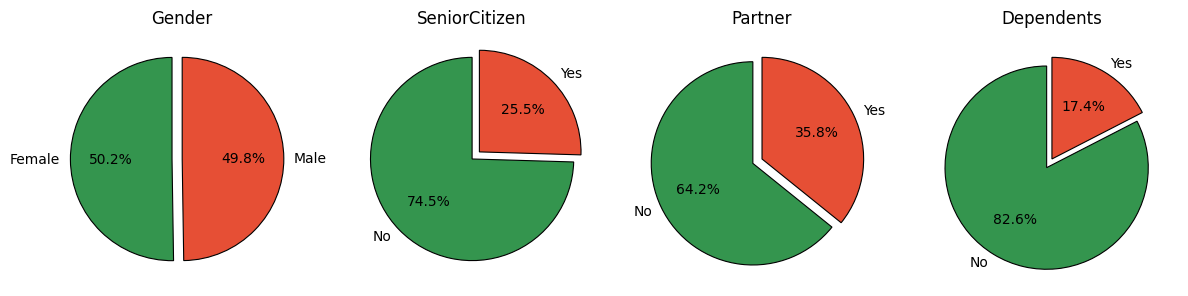

In [30]:
# Plot Customer Demographics ratio who Churned
customer_demographics_props = {}
for feature in customer_demographics:
    churn_counts = data_copy[data_copy['Churn'] == 1][feature].value_counts(normalize=True) * 100
    customer_demographics_props[feature] = []
    for i in range(len(churn_counts)):
        customer_demographics_props[feature].append(churn_counts[i])

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 12))
ax = axes[0]
ax.pie(customer_demographics_props['gender'],
       labels=['Female', 'Male'],
       autopct='%1.1f%%', startangle=90,
       explode=(0.1, 0),
       colors=colors,
       wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
ax.set_title('Gender')

ax = axes[1]
ax.pie(customer_demographics_props['SeniorCitizen'],
       labels=['No', 'Yes'],
       autopct='%1.1f%%', startangle=90,
       explode=(0, 0.1),
       colors=colors,
       wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
ax.set_title('SeniorCitizen')

ax = axes[2]
ax.pie(customer_demographics_props['Partner'],
       labels=['No', 'Yes'],
       autopct='%1.1f%%', startangle=90,
       explode=(0.1, 0),
       colors=colors,
       wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
ax.set_title('Partner')

ax = axes[3]
ax.pie(customer_demographics_props['Dependents'],
       labels=['No', 'Yes'],
       autopct='%1.1f%%', startangle=90,
       explode=(0.1, 0),
       colors=colors,
       wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
ax.set_title('Dependents')

plt.tight_layout()
plt.show()

- The churn rates between Female and Male groups is almost equal.
- 74.5 % of the churned customers are senior citizens, making them the high-risk group.
- Cutomers who do not have partner are more likely to churn.
- Nearly 83% of churned customers are living on there own.

#### Group 2: Services subscribed

##### Phone Services

In [31]:
for service in services_signed_up['Phone Services']:
    print(f"{service}: {data[service].unique()} -> {data_copy[service].unique()}")

PhoneService: ['No' 'Yes'] -> [0 1]
MultipleLines: ['No phone service' 'No' 'Yes'] -> [1 0 2]


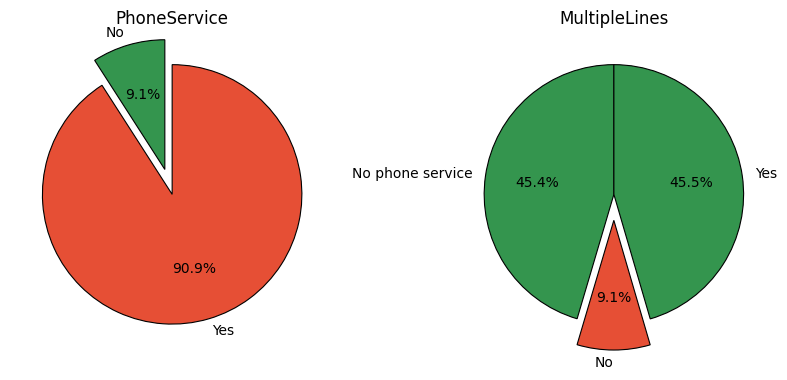

In [32]:
# Phone Services
phone_services_props = {}
for feature in services_signed_up['Phone Services']:
    churn_counts = data_copy[data_copy['Churn'] == 1][feature].value_counts(normalize=True) * 100
    phone_services_props[feature] = []
    for i in range(len(churn_counts)):
        phone_services_props[feature].append(churn_counts[i])

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 8))
ax = axes[0]
ax.pie(phone_services_props['PhoneService'],
       labels=['No', 'Yes'],
       autopct='%1.1f%%', startangle=90,
       explode=(0.2, 0),
       colors=colors,
       wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
ax.set_title('PhoneService')

ax = axes[1]
ax.pie(phone_services_props['MultipleLines'],
       labels=['No phone service', 'No', 'Yes'],
       autopct='%1.1f%%', startangle=90,
       explode=(0, 0.2, 0),
       colors=colors,
       wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
ax.set_title('MultipleLines')

plt.tight_layout()
plt.show()

- 90.9% of churned customers have PhoneService
- 9.1% of churned customers prefers single line rather than multiple lines and churn rate is similar between the customers sho had multiple lines and those who do not have phone service at all.

##### Internet Services

In [33]:
for service in services_signed_up['Internet Services']:
    print(f"{service}: {data[service].unique()}, {data_copy[service].unique()}")

InternetService: ['DSL' 'Fiber optic' 'No'], [0 1 2]
OnlineSecurity: ['No' 'Yes' 'No internet service'], [0 2 1]
OnlineBackup: ['Yes' 'No' 'No internet service'], [2 0 1]
DeviceProtection: ['No' 'Yes' 'No internet service'], [0 2 1]
TechSupport: ['No' 'Yes' 'No internet service'], [0 2 1]


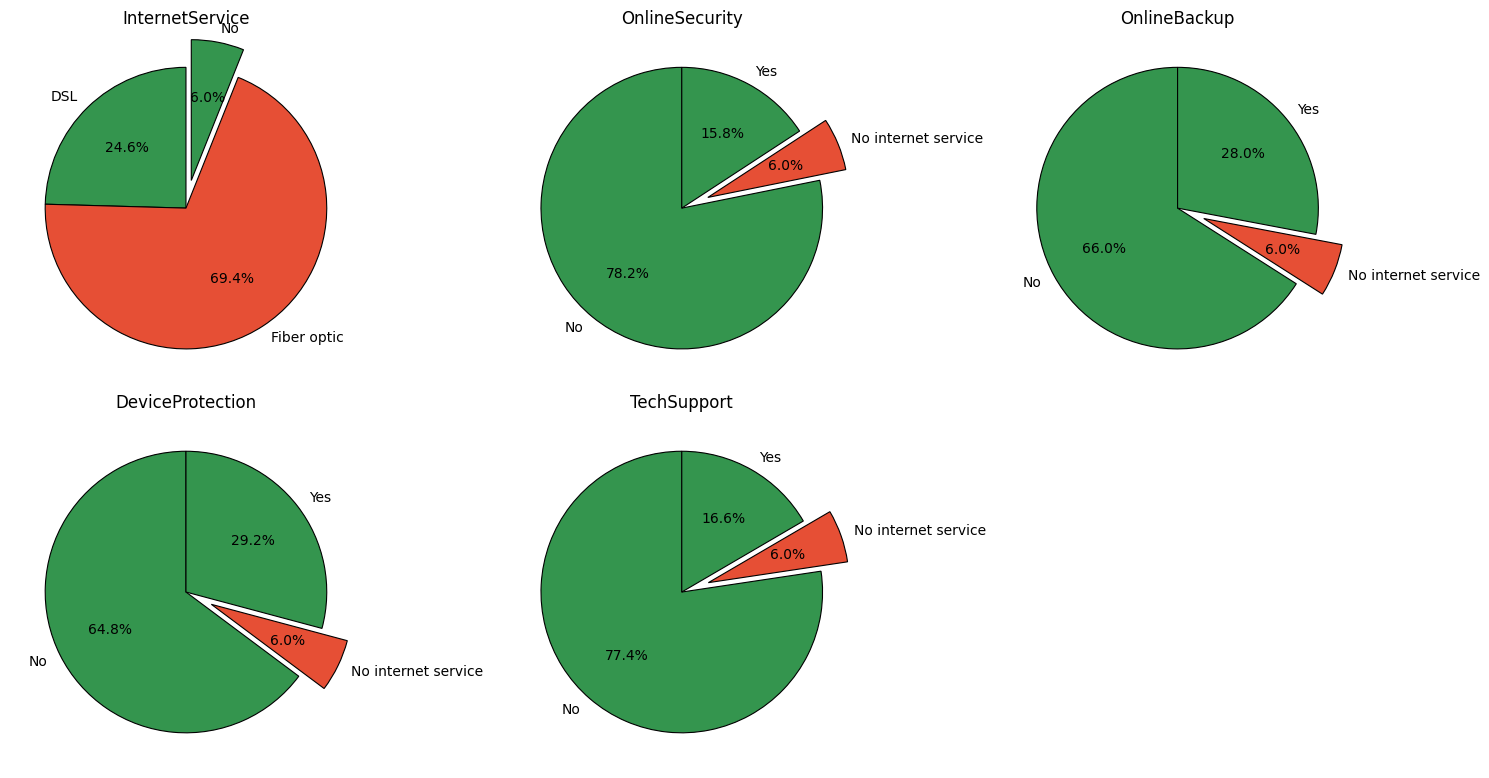

In [34]:
# Internet Services
internet_services_props = {}
for feature in services_signed_up['Internet Services']:
    churn_counts = data_copy[data_copy['Churn'] == 1][feature].value_counts(normalize=True) * 100
    internet_services_props[feature] = []
    for i in range(len(churn_counts)):
        internet_services_props[feature].append(churn_counts[i])

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 15))
axes = axes.flatten()
ax = axes[0]
ax.pie(internet_services_props['InternetService'],
       labels=['DSL', 'Fiber optic', 'No'],
       autopct='%1.1f%%', startangle=90,
       explode=(0, 0, 0.2),
       colors=colors,
       wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
ax.set_title('InternetService')

ax = axes[1]
ax.pie(internet_services_props['OnlineSecurity'],
       labels=['No', 'No internet service', 'Yes'],
       autopct='%1.1f%%', startangle=90,
       explode=(0, 0.2, 0),
       colors=colors,
       wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
ax.set_title('OnlineSecurity')

ax = axes[2]
ax.pie(internet_services_props['OnlineBackup'],
       labels=['No', 'No internet service', 'Yes'],
       autopct='%1.1f%%', startangle=90,
       explode=(0, 0.2, 0),
       colors=colors,
       wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
ax.set_title('OnlineBackup')

ax = axes[3]
ax.pie(internet_services_props['DeviceProtection'],
       labels=['No', 'No internet service', 'Yes'],
       autopct='%1.1f%%', startangle=90,
       explode=(0, 0.2, 0),
       colors=colors,
       wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
ax.set_title('DeviceProtection')

ax = axes[4]
ax.pie(internet_services_props['TechSupport'],
       labels=['No', 'No internet service', 'Yes'],
       autopct='%1.1f%%', startangle=90,
       explode=(0, 0.2, 0),
       colors=colors,
       wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
ax.set_title('TechSupport')

# Remove any extra axes
for j in range(len(services_signed_up['Internet Services']), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.subplots_adjust(top=0.55)
plt.show()

- Majority of the churned customers are customers who subscribed for Fiber optic service compared to DSL and no internet service.
- On an average 77.8% of churned customers did not enabled OnlineSecurity and TechSupport services, making them the high risk group.
- On an average 65.4% percent of customers did not enabled the OnlineBackup and DeviceProtection services.

##### Streaming Services

In [35]:
for service in services_signed_up['Streaming Services']:
    print(f"{service}: {data[service].unique()}, {data_copy[service].unique()}")

StreamingTV: ['No' 'Yes' 'No internet service'], [0 2 1]
StreamingMovies: ['No' 'Yes' 'No internet service'], [0 2 1]


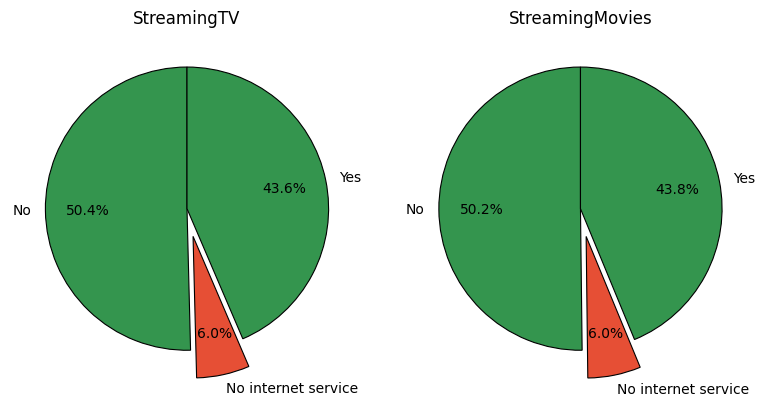

In [36]:
# Streaming Services
streaming_services_props = {}
for feature in services_signed_up['Streaming Services']:
    churn_counts = data_copy[data_copy['Churn'] == 1][feature].value_counts(normalize=True) * 100
    streaming_services_props[feature] = []
    for i in range(len(churn_counts)):
        streaming_services_props[feature].append(churn_counts[i])

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 8))
axes = axes.flatten()
ax = axes[0]
ax.pie(streaming_services_props['StreamingTV'],
       labels=['No', 'No internet service', 'Yes'],
       autopct='%1.1f%%', startangle=90,
       pctdistance=0.7,
       explode=(0, 0.2, 0),
       colors=colors,
       wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
ax.set_title('StreamingTV')

ax = axes[1]
ax.pie(streaming_services_props['StreamingMovies'],
       labels=['No', 'No internet service', 'Yes'],
       autopct='%1.1f%%', startangle=90,
       pctdistance=0.7,
       explode=(0, 0.2, 0),
       colors=colors,
       wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
ax.set_title('StreamingMovies')

plt.tight_layout()
plt.show()

For both streaming services (StreamingTV and StreamingMovies), churned customers – those who enabled and did not enable these services – are equally proportioned.

#### Group 3: Payment Info

In [37]:
for service in payment_info:
    print(f"{service}: {data[service].unique()}, {data_copy[service].unique()}")

Contract: ['Month-to-month' 'One year' 'Two year'], [0 1 2]
PaperlessBilling: ['Yes' 'No'], [1 0]
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)'], [2 3 0 1]


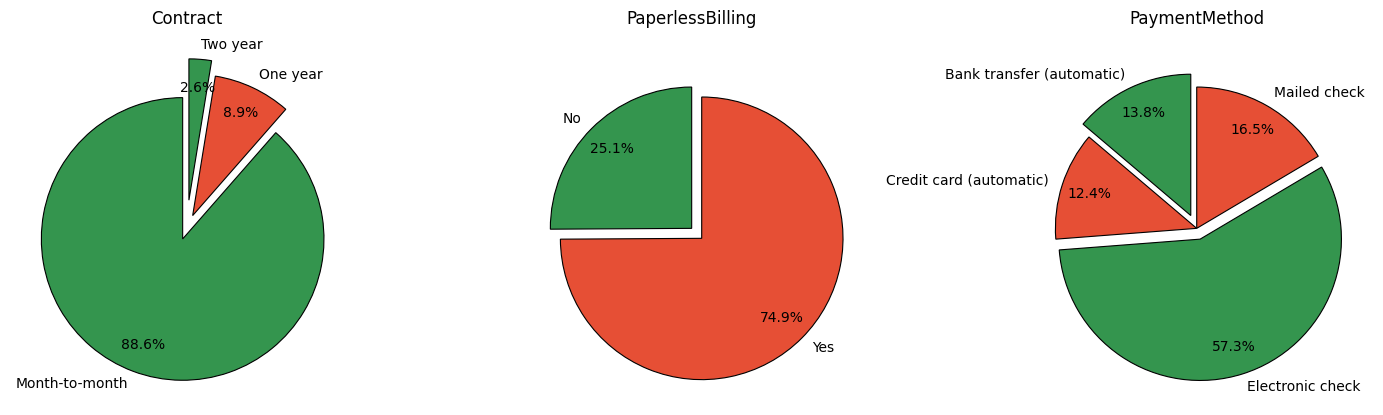

In [38]:
# Payment Info
payment_info_props = {}
for feature in payment_info:
    churn_counts = data_copy[data_copy['Churn'] == 1][feature].value_counts(normalize=True) * 100
    payment_info_props[feature] = []
    for i in range(len(churn_counts)):
        payment_info_props[feature].append(churn_counts[i])

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 5))
axes = axes.flatten()

# Contract
ax = axes[0]
ax.pie(payment_info_props['Contract'],
       labels=['Month-to-month', 'One year', 'Two year'],
       autopct='%1.1f%%', startangle=90,
       pctdistance=0.8,
       explode=(0.08, 0.1, 0.2),
       colors=colors,
       wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
ax.set_title('Contract', pad=20)

# PaperlessBilling
ax = axes[1]
ax.pie(payment_info_props['PaperlessBilling'],
       labels=['No', 'Yes'],
       autopct='%1.1f%%', startangle=90,
       pctdistance=0.8,
       explode=(0, 0.1),
       colors=colors,
       wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
ax.set_title('PaperlessBilling', pad=20)

# PaymentMethod
ax = axes[2]
ax.pie(payment_info_props['PaymentMethod'],
       labels=['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check'],
       autopct='%1.1f%%', startangle=90,
       pctdistance=0.8,
       explode=(0.1, 0, 0.08, 0),
       colors=colors,
       wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
ax.set_title('PaymentMethod', pad=20)

plt.tight_layout()
plt.show()

- With an enormous 88.6% of consumers, month-to-month contracts have the largest proportion of churning.
- 75% of the churned customers have enabled PaperlessBilling.
- Because electronic checks cause 57.3% of churn, they must undoubtedly be fixed, followed by mailed cheque, an automatic bank transfer and an automatic credit card.

### Numerical features vs target

#### Numerical features distribution

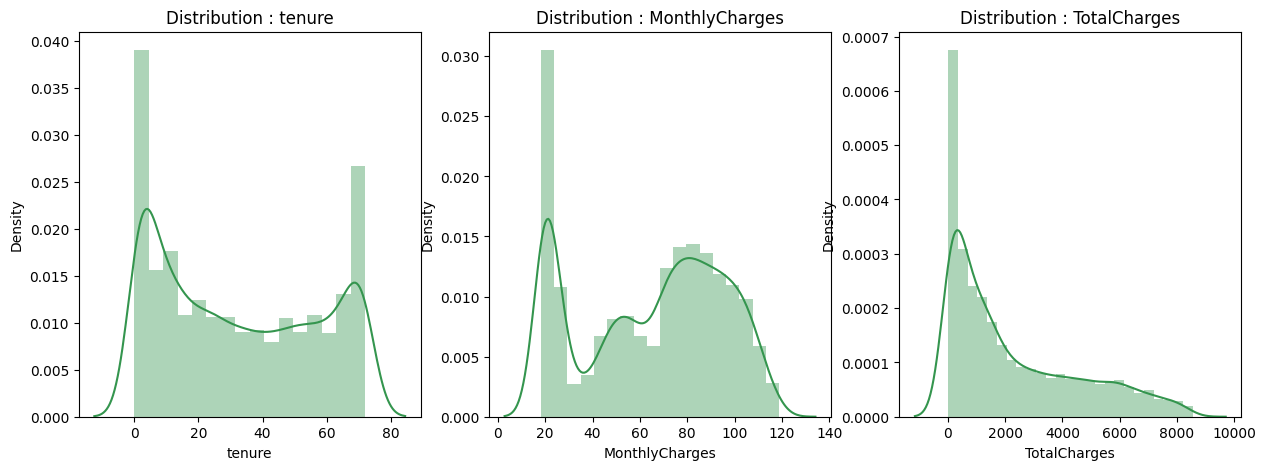

In [39]:
fig, ax = plt.subplots(nrows = 1,ncols = 3,figsize = (15,5))
for i in range(len(num_features)):
    plt.subplot(1,3,i+1)
    sns.distplot(data_copy[num_features[i]],color = colors[0])
    title = 'Distribution : ' + num_features[i]
    plt.title(title)
plt.show()

- Tenure and MonthlyCharges kind of create a bimodal distribution with peaks present at 0 - 70 and 20 - 80 respectively.
- TotalCharges displays a positively or rightly skewed distribution.

#### Correlation of Numerical features with Churn

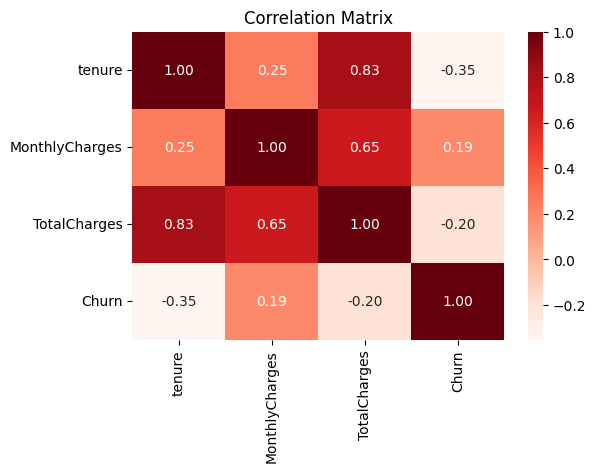

In [40]:
plt.figure(figsize=(6,4))
sns.heatmap(data_copy[num_features + ['Churn']].corr(), annot=True, cmap='Reds', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

- High multicollinearity exists between `tenure` and `TotalCharges` (0.83). This is expected, as customers with longer tenure naturally accumulate higher total charges.
- `tenure` has the strongest negative correlation with `Churn` (-0.35). This means as tenure increases (customers stay longer), churn tends to decrease.
- `TotalCharges` has a moderate negative correlation with `Churn` (-0.20), also indicating that higher total charges are associated with less churn.
- `MonthlyCharges` has a weak positive correlation with `Churn` (0.19), suggesting that higher monthly charges are slightly associated with more churn.

#### Distribution of numerical features grouped by Churn.

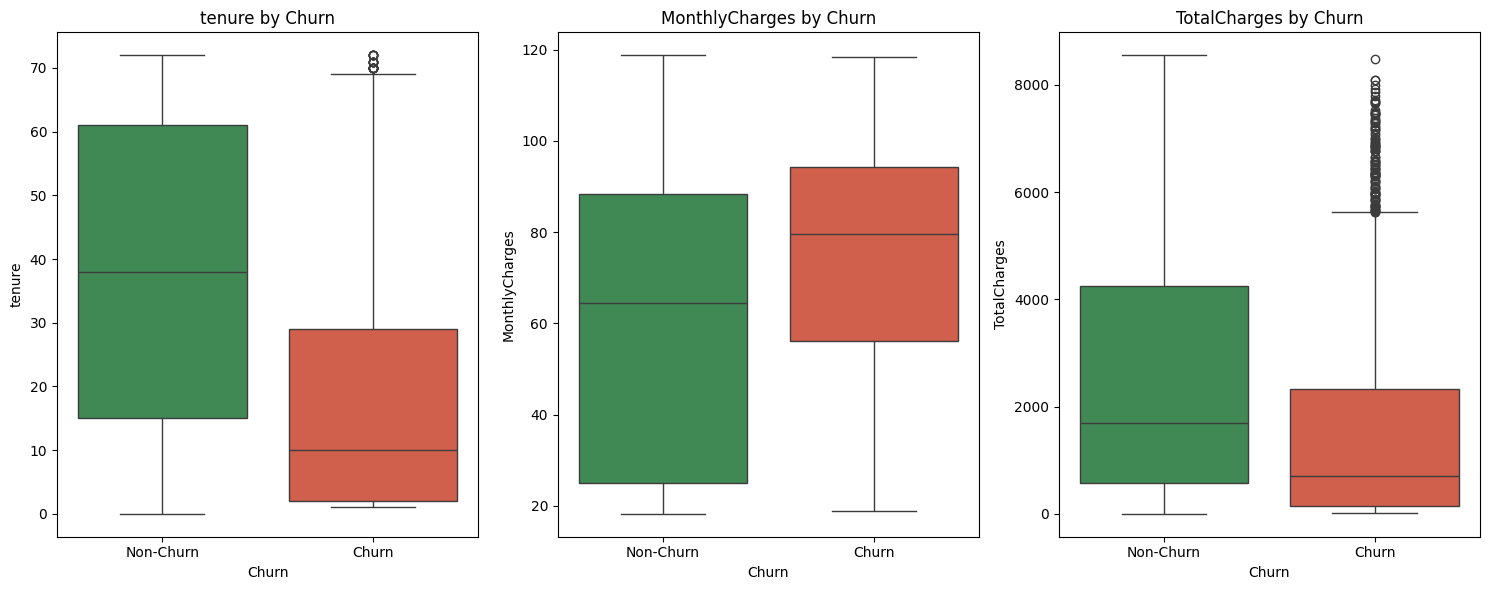

In [41]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,6))
axes = axes.flatten()
for i, feature in enumerate(num_features):
    ax = axes[i]
    sns.boxplot(x='Churn', y=feature, data=data_copy, palette=colors, ax=ax)
    ax.set_title(f'{feature} by Churn')
    ax.set_xticklabels(['Non-Churn', 'Churn'])
plt.tight_layout()
plt.show()

- Non-churn customers have a much higher median tenure (around 38-40 months) and a broader distribution compared to churn customers, whose median tenure is very low (around 10 months).
- Churn customers tend to have slightly higher median MonthlyCharges (around $80-90) compared to non-churn customers (around $60-70).
- Non-churn customers have much higher median TotalCharges (around $2000) than churn customers (around $500). This indicates that customers who accumulate less total spending are far more likely to churn.

Outliers:
- Fewer outliers are present in churned group with higher tenure.
- Extreme outliers are present in the churned group with higher TotalCharges.

## Based on this EDA
Based on the comprehensive analysis of customer churn data, we've identified key patterns and risk factors that drive customer attrition in the telecom industry. The analysis reveals a 26.5% churn rate (1,869 churned customers out of 7,043 total customers), which represents a **moderate class imbalance** that requires careful handling in predictive modeling.

**Key Risk Factors Identified:**
1. Contract & Payment Behavior (Highest Risk)
    - `Month-to-month contracts`: 88.6% of churned customers
    - `Electronic check payments`: 57.3% of churned customers
    - `Paperless billing`: 75% of churned customers

Short-term commitments combined with less reliable payment methods create the highest churn risk.

2. Customer Demographics
    - Senior citizens: 74.5% higher churn propensity
    - No partner: Customers without partners more likely to churn
    - No dependents: 83% of churned customers live alone

Isolated customer segments require targeted retention strategies.

3. Service Utilization Patterns
    - Fiber optic users: Higher churn despite premium service
    - Low value-added services adoption:
        * 77.8% of churned customers didn't use OnlineSecurity/TechSupport
        * 65.4% didn't use OnlineBackup/DeviceProtection

Premium service users paradoxically show higher churn, indicating service quality or pricing issues.

4. Financial Indicators
    - Lower tenure: Median 10 months vs 38-40 months for retained customers
    - Higher monthly charges: ~$80-90 vs $60-70 for retained customers
    - Lower total charges: ~$500 vs $2000 for retained customers

New customers with high monthly fees but low total spending are at extreme risk.


Overall:
- Tenure is the strongest negative correlate with churn.
- Month-to-month contracts, paperless billing, and electronic checks are risk factors.
- Senior citizens, non-partners, and those without dependents are more likely to churn.
- Subscriptions to OnlineSecurity, TechSupport, and DeviceProtection reduce churn.



## Feature Engineering and Preprocessing Pipeline

In [42]:
# Define feature categories based on transforming strategy
binary_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
already_encoded = ['SeniorCitizen']
ordinal_features = {
    'Contract': ['Month-to-month', 'One year', 'Two year']  # Increasing commitment
}
nominal_features = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaymentMethod'
]
categorical_features = binary_features + list(ordinal_features.keys()) + nominal_features + already_encoded
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [43]:
data.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

### Numerical Pipeline

In [44]:
data[['MonthlyCharges', 'tenure', 'TotalCharges']].assign(total_charges=lambda x: x['MonthlyCharges'] * x['tenure']).head()

,MonthlyCharges,tenure,TotalCharges,total_charges
0,29.85,1,29.85,29.85
1,56.95,34,1889.50,1936.30
2,53.85,2,108.15,107.70
3,42.30,45,1840.75,1903.50
4,70.70,2,151.65,141.40


Let's re-calculate the Total Charges to make sure it is right.

In [45]:
from sklearn.base import BaseEstimator, TransformerMixin

class TotalChargesRecalculator(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self  # Nothing to fit

    def transform(self, X):
        X = X.copy()
        X['TotalCharges'] = X['MonthlyCharges'] * X['tenure']
        return X

tc = TotalChargesRecalculator()
tc.fit_transform(data[num_features])

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1936.30
2,2,53.85,107.70
3,45,42.30,1903.50
4,2,70.70,141.40
...,...,...,...
7038,24,84.80,2035.20
7039,72,103.20,7430.40
7040,11,29.60,325.60
7041,4,74.40,297.60


In [46]:
(tc.fit_transform(data[num_features])
 .isna().sum()
)

tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64

In [47]:
(tc.fit_transform(data[num_features])
 .query('TotalCharges.isna()')
)

,tenure,MonthlyCharges,TotalCharges


There are no rows where TotalCharges has NaN values, which might be the 0. Let's investigate where TotalCharges is 0.

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn import set_config
set_config(transform_output='pandas')

numerical_pipe = Pipeline(steps=[
    ('total_charges_rec', TotalChargesRecalculator()), # Re-calculate TotalCharges
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)), # Handles NaN in any of the numerical features
    ('scaler', StandardScaler())
])

numerical_pipe.fit_transform(data[numerical_features])

,tenure,MonthlyCharges,TotalCharges
0,-1.28,-1.16,-0.99
1,0.07,-0.26,-0.15
2,-1.24,-0.36,-0.96
3,0.51,-0.75,-0.17
4,-1.24,0.20,-0.94
...,...,...,...
7038,-0.34,0.67,-0.11
7039,1.61,1.28,2.27
7040,-0.87,-1.17,-0.86
7041,-1.16,0.32,-0.88


In [49]:
(
    numerical_pipe.fit_transform(data[numerical_features])
    .isna()
    .sum()
)

tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64

In [50]:
# See where the missing values are filled
(numerical_pipe
 .fit_transform(data[num_features])
 .loc[data['TotalCharges'].isna()]
)

,tenure,MonthlyCharges,TotalCharges
488,-1.32,-0.41,-1.01
753,-1.32,-1.48,-1.01
936,-1.32,0.53,-1.01
1082,-1.32,-1.30,-1.01
1340,-1.32,-0.29,-1.01
3331,-1.32,-1.49,-1.01
3826,-1.32,-1.31,-1.01
4380,-1.32,-1.49,-1.01
5218,-1.32,-1.50,-1.01
6670,-1.32,0.29,-1.01


### Categorical Pipeline

In [51]:
for cat_feature in cat_features:
    print(f"{cat_feature}: {data[cat_feature].unique()}")

gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [52]:
(data
 .select_dtypes(object)
 .nunique()
)

gender              2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaperlessBilling    2
PaymentMethod       4
Churn               2
dtype: int64

As we have low cardinality, there will no problem when we one-hot encode the categorical features.

#### Binary Features Encoding

In [53]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Binary Features Transformer (Manual Label Encoding for Yes/No)
class BinaryEncoder:
    def __init__(self):
        self.feature_mappings_ = {}
    
    def fit(self, X, y=None):
        for col in X.columns:
            unique_vals = X[col].unique()
            if len(unique_vals) == 2:
                # Create mapping: typically 'No'->0, 'Yes'->1 or 'Female'->0, 'Male'->1
                if 'No' in unique_vals and 'Yes' in unique_vals:
                    self.feature_mappings_[col] = {'No': 0, 'Yes': 1}
                elif 'Female' in unique_vals and 'Male' in unique_vals:
                    self.feature_mappings_[col] = {'Female': 0, 'Male': 1}
                else:
                    # Fallback: alphabetical order
                    sorted_vals = sorted(unique_vals)
                    self.feature_mappings_[col] = {sorted_vals[0]: 0, sorted_vals[1]: 1}
        return self
    
    def transform(self, X):
        X_transformed = X.copy()
        for col in X.columns:
            if col in self.feature_mappings_:
                X_transformed[col] = X[col].map(self.feature_mappings_[col])
        return X_transformed
    
    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

binary_transformer = Pipeline(steps=[
    ('encoder', BinaryEncoder())
])

binary_transformer.fit_transform(data[binary_features])

,gender,Partner,Dependents,PhoneService,PaperlessBilling
0,0,1,0,0,1
1,1,0,0,1,0
2,1,0,0,1,1
3,1,0,0,0,0
4,0,0,0,1,1
...,...,...,...,...,...
7038,1,1,1,1,1
7039,0,1,1,1,1
7040,0,1,1,0,1
7041,1,1,0,1,1


#### Ordinal Feature Encoding

In [54]:
ordinal_features

{'Contract': ['Month-to-month', 'One year', 'Two year']}

In [55]:
# Ordinal transformer for Contract (Month-to-month < One year < Two year)
ordinal_transformer = Pipeline(steps=[
    ('encoder', OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']]))
])

ordinal_transformer.fit_transform(data[list(ordinal_features.keys())])

,Contract
0,0.00
1,1.00
2,0.00
3,1.00
4,0.00
...,...
7038,1.00
7039,1.00
7040,0.00
7041,0.00


#### Nominal Feature Encoding

In [56]:
nominal_features

['MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'PaymentMethod']

In [57]:
# One-hot encoder for nominal features
nominal_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))
])

nominal_transformer.fit_transform(data[nominal_features])

,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
1,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
2,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
3,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00
7039,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,1.00,0.00,0.00
7040,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
7041,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


#### Final Categorical Pipeline

In [58]:
from sklearn.compose import ColumnTransformer

categorical_pipe = ColumnTransformer(
    transformers=[
        ('binary', binary_transformer, binary_features),
        ('ordinal', ordinal_transformer, list(ordinal_features.keys())),
        ('nominal', nominal_transformer, nominal_features)
    ],
    remainder='passthrough', # Keep any remaining columns as-is
)

categorical_pipe.fit_transform(data[cat_features])

,binary__gender,binary__Partner,binary__Dependents,binary__PhoneService,binary__PaperlessBilling,ordinal__Contract,nominal__MultipleLines_No phone service,nominal__MultipleLines_Yes,nominal__InternetService_Fiber optic,nominal__InternetService_No,...,nominal__TechSupport_No internet service,nominal__TechSupport_Yes,nominal__StreamingTV_No internet service,nominal__StreamingTV_Yes,nominal__StreamingMovies_No internet service,nominal__StreamingMovies_Yes,nominal__PaymentMethod_Credit card (automatic),nominal__PaymentMethod_Electronic check,nominal__PaymentMethod_Mailed check,remainder__SeniorCitizen
0,0,1,0,0,1,0.00,1.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0
1,1,0,0,1,0,1.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0
2,1,0,0,1,1,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0
3,1,0,0,0,0,1.00,1.00,0.00,0.00,0.00,...,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0
4,0,0,0,1,1,0.00,0.00,0.00,1.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,1,1,1,1,1.00,0.00,1.00,0.00,0.00,...,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0
7039,0,1,1,1,1,1.00,0.00,1.00,1.00,0.00,...,0.00,0.00,0.00,1.00,0.00,1.00,1.00,0.00,0.00,0
7040,0,1,1,0,1,0.00,1.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0
7041,1,1,0,1,1,0.00,0.00,1.00,1.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1


### Complete Preprocessing Pipeline

In [59]:
# Complete preprocessing pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from collections import Counter

from sklearn import set_config
set_config(transform_output='pandas')

# Custom class transformer for handling TotalCharges
class TotalChargesRecalculator(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self  # Nothing to fit

    def transform(self, X):
        X = X.copy()
        X['TotalCharges'] = X['MonthlyCharges'] * X['tenure']
        return X
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array(numerical_features)
        return np.array(input_features)

# Binary Features Transformer (Manual Label Encoding for Yes/No)
class BinaryEncoder:
    def __init__(self):
        self.feature_mappings_ = {}
    
    def fit(self, X, y=None):
        for col in X.columns:
            unique_vals = X[col].unique()
            if len(unique_vals) == 2:
                # Create mapping: typically 'No'->0, 'Yes'->1 or 'Female'->0, 'Male'->1
                if 'No' in unique_vals and 'Yes' in unique_vals:
                    self.feature_mappings_[col] = {'No': 0, 'Yes': 1}
                elif 'Female' in unique_vals and 'Male' in unique_vals:
                    self.feature_mappings_[col] = {'Female': 0, 'Male': 1}
                else:
                    # Fallback: alphabetical order
                    sorted_vals = sorted(unique_vals)
                    self.feature_mappings_[col] = {sorted_vals[0]: 0, sorted_vals[1]: 1}
        return self
    
    def transform(self, X):
        X_transformed = X.copy()
        for col in X.columns:
            if col in self.feature_mappings_:
                X_transformed[col] = X[col].map(self.feature_mappings_[col])
        return X_transformed
    
    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array(self.feature_mappings_.keys())
        return np.array(input_features)

# --- Debug Transformer function ---
class DebugTransformer(BaseEstimator, TransformerMixin):
    """Silently captures X and y during the .fit() call for later inspection."""
    def __init__(self, name_X='X_debug', name_y='y_debug'):
        self.name_X = name_X
        self.name_y = name_y
    def fit(self, X, y=None):
        if y is not None:
            globals()[self.name_X] = X.copy()
            globals()[self.name_y] = pd.Series(y).copy() if hasattr(y, 'copy') else pd.Series(y)
        return self
    def transform(self, X):
        return X

# ----- Complete preprocessing pipeline -----
def create_preprocessing_pipeline():
    # Numerical Pipeline
    numerical_pipe = Pipeline(steps=[
        ('total_charges_rec', TotalChargesRecalculator()), # Re-calculate TotalCharges
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)), # Handles NaN in any of the numerical features
    ])
    
    # Categorical Pipeline
    binary_transformer = Pipeline(steps=[
        ('encoder', BinaryEncoder())
    ])
    
    ordinal_transformer = Pipeline(steps=[
        ('encoder', OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']]))
    ])
    
    nominal_transformer = Pipeline(steps=[
        ('encoder', OneHotEncoder(drop='first', sparse_output=False))
    ])

    categorical_pipe = ColumnTransformer(
        transformers=[
            ('binary_cat', binary_transformer, binary_features),
            ('ordinal_cat', ordinal_transformer, list(ordinal_features.keys())),
            ('nominal_cat', nominal_transformer, nominal_features)
        ],
        remainder='passthrough' # Keep any remaining columns as-is
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ('num_pipe', numerical_pipe, numerical_features),
            ('cat_pipe', categorical_pipe, cat_features)
        ]
    )
            
    return preprocessor

In [60]:
create_preprocessing_pipeline()

ColumnTransformer(transformers=[('num_pipe',
                                 Pipeline(steps=[('total_charges_rec',
                                                  TotalChargesRecalculator()),
                                                 ('imputer',
                                                  SimpleImputer(fill_value=0,
                                                                strategy='constant'))]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('cat_pipe',
                                 ColumnTransformer(remainder='passthrough',
                                                   transformers=[('binary_cat',
                                                                  Pipeline(steps=[('encoder',
                                                                                   <__main__.BinaryEncoder obj...
                                                                   'OnlineSecurity',
                                                                   'OnlineBackup',
                                                                   'DeviceProtection',
                                                                   'TechSupport',
                                                                   'StreamingTV',
                                                                   'StreamingMovies',
                                                                   'PaymentMethod'])]),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

## Feature Selection

In [61]:
data_preprocessed = create_preprocessing_pipeline().fit_transform(raw)
data_preprocessed.head()

,num_pipe__tenure,num_pipe__MonthlyCharges,num_pipe__TotalCharges,cat_pipe__binary_cat__gender,cat_pipe__binary_cat__Partner,cat_pipe__binary_cat__Dependents,cat_pipe__binary_cat__PhoneService,cat_pipe__binary_cat__PaperlessBilling,cat_pipe__ordinal_cat__Contract,cat_pipe__nominal_cat__MultipleLines_No phone service,...,cat_pipe__nominal_cat__TechSupport_No internet service,cat_pipe__nominal_cat__TechSupport_Yes,cat_pipe__nominal_cat__StreamingTV_No internet service,cat_pipe__nominal_cat__StreamingTV_Yes,cat_pipe__nominal_cat__StreamingMovies_No internet service,cat_pipe__nominal_cat__StreamingMovies_Yes,cat_pipe__nominal_cat__PaymentMethod_Credit card (automatic),cat_pipe__nominal_cat__PaymentMethod_Electronic check,cat_pipe__nominal_cat__PaymentMethod_Mailed check,cat_pipe__remainder__SeniorCitizen
0,1.00,29.85,29.85,0,1,0,0,1,0.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0
1,34.00,56.95,1936.30,1,0,0,1,0,1.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0
2,2.00,53.85,107.70,1,0,0,1,1,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0
3,45.00,42.30,1903.50,1,0,0,0,0,1.00,1.00,...,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0
4,2.00,70.70,141.40,0,0,0,1,1,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0


In [62]:
target = raw['Churn'].map({'No': 0, 'Yes': 1})
target.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

### Numerical features

As this is a classifiaction task, we are using

**ANOVA F-test**: Measures the linear dependency between numerical features and a categorical target. It evaluates if the means of different classes are significantly different for each feature. Assumes normally distributed data within each class.

In [63]:
from sklearn.feature_selection import SelectKBest, f_classif

num = [col for col in data_preprocessed.columns if col.startswith("num_pipe__")]
X_num = data_preprocessed[num]

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_num, target)
for name, score in zip(num, selector.scores_):
    print(f"{name}: {score:.4f}")

num_pipe__tenure: 997.2680
num_pipe__MonthlyCharges: 273.4637
num_pipe__TotalCharges: 288.8541


Higher F-score means stronger class-separating power. but for this data we as there are only three numerical features we can and their F scores are acceptable, we can include them all for modeling.

### Categorical features

Here we are using **Chi-Sq** test for feature selection for categorical features.

Note: Chi-Squared requires non-negative values, so encoding pipelines (e.g., OneHotEncoder, BinaryEncoder) ensure this condition.

When your OneHotEncoder expands a categorical feature into multiple binary indicator columns (one per category), the chi-squared test returns separate scores for each category column. This creates a challenge: how do you select the best **original categorical features** based on these multiple per-category chi-squared scores?

Here are common approaches:
- Aggregate Chi-Squared Scores per Original Feature:
    * Maximum Chi-Squared Score: Can highlight such dominant categories within a feature, potentially ignoring weaker categories.
    * Sum of Chi-Squared Scores: Can overvalue features with many categories even if individual categories are weak.
    * Mean Chi-Squared Score: Balanced and often safer when category counts vary.
- Aggregate aorresponding p-values per Original Feature
- Select Based on p-value (features with low p-values are considered more strongly associated with the target)

We go with **mean aggregation**, because it balances the influence of features regardless of category count.

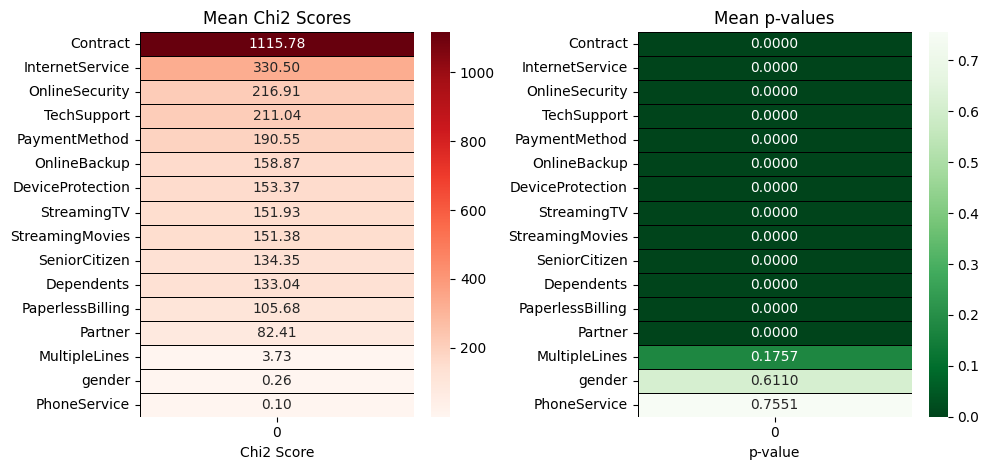

In [64]:
from sklearn.feature_selection import chi2

cat_feature_cols = [col for col in data_preprocessed.columns if col.startswith("cat_pipe__")]
X_cat = data_preprocessed[cat_feature_cols]

chi2_scores, p_values = chi2(X_cat, target)

scores_df = (
    pd.DataFrame({'feature': [name.split('__')[-1] for name in cat_feature_cols],
                  'chi2_score': chi2_scores,
                  'p_value': p_values})
    .assign(feature_original=lambda df: df['feature'].str.split('_').str[0])
    .sort_values(by='p_value', ascending=True)
)

agg_scores = scores_df.groupby('feature_original').agg({
    'chi2_score': 'mean',
    'p_value': 'mean'
}).sort_values(by='chi2_score', ascending=False)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, len(agg_scores)*0.3))
sns.heatmap(
    agg_scores[['chi2_score']].values,
    yticklabels=agg_scores.index,
    annot=True, fmt='.2f',
    cmap='Reds',
    cbar=True,
    linewidths=0.5,
    linecolor='black',
    ax=axes[0]
)
axes[0].set_title('Mean Chi2 Scores')
axes[0].set_xlabel('Chi2 Score')

sns.heatmap(
    agg_scores[['p_value']].values,
    yticklabels=agg_scores.index,
    annot=True, fmt='.4f',
    cmap='Greens_r',
    cbar=True,
    linewidths=0.5,
    linecolor='black',
    ax=axes[1]
)
axes[1].set_title('Mean p-values')
axes[1].set_xlabel('p-value')

plt.tight_layout()
plt.show()

**Statistical Test Summary:**
- Chi-squared test suggests `MultipleLines`, `gender`, and `PhoneService` are statistically not significant at the 0.05 level for predicting churn.

**EDA confirms:**
- `gender`: truly uninformative - **Drop**
- `PhoneService`: Redundant with MultipleLines (Overlap with `No phone service` category) - **Drop**
- `MultipleLines`: Have predictive power - **We will try with and without MultipleLines**

## Modeling

### Prepare Data
By performing the train-test split after removing any unnecessary features and before fitting any sklearn transformers, you prevent those features from influencing any pipeline steps.

In [65]:
from sklearn.model_selection import train_test_split

def prepare_data(data, drop_columns=None, target='Churn', target_mapping=None, test_size=0.2, random_state=42, stratify=True):
    """
    Prepare features and target for modeling, including initial data cleaning.
    Args:
        data (pd.DataFrame): The raw input DataFrame.
        drop_columns (list): List of columns to drop before modeling.
        target_column (str): The name of the target column.
        target_mapping (dict, optional): Mapping to convert target column to numeric.
                                         If None, auto-map all unique values to ints.
        test_size (float): Fraction of data to reserve as test set.
        random_state (int): Random seed for reproducibility.
        stratify (bool): Whether to stratify the split on the target column.
    Returns:
        tuple: X_train, X_test, y_train, y_test
    """
    df = data.copy()

    # Clean TotalCharges if presentn (replace spaces with NaN, then convert to float)
    if 'TotalCharges' in df.columns:
        df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
        df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

    # Drop the features that are not useful prediction
    if drop_columns is None:
        drop_columns = []
    df.drop(columns=list(set(drop_columns)), inplace=True, errors='ignore')

    # Target column mapping
    y = df[target]
    if target_mapping is None:
        classes = list(pd.Series(y).unique())
        target_mapping = {label: idx for idx, label in enumerate(classes)}
    y = y.map(target_mapping)   

    # Feature matrix
    X = df.drop(columns=[target], errors='ignore')
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y if stratify else None
    )
    
    return X_train, X_test, y_train, y_test

In [66]:
X_train, X_test, y_train, y_test = prepare_data(
    raw,
    drop_columns=['customerID', 'gender', 'PhoneService'], # Features not useful for churn prediction
    target='Churn', 
    test_size=0.2, 
    random_state=42, 
    stratify=True
)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 17)
y_train shape: (5634,)
X_test shape: (1409, 17)
y_test shape: (1409,)


In [67]:
# Define feature categories based on transforming strategy
binary_features = ['Partner', 'Dependents', 'PaperlessBilling']
already_encoded = ['SeniorCitizen']
ordinal_features = {
    'Contract': ['Month-to-month', 'One year', 'Two year']  # Increasing commitment
}
nominal_features = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaymentMethod'
]
cat_features = binary_features + list(ordinal_features.keys()) + nominal_features + already_encoded
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

### Evaluation function

In [68]:
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, f1_score, accuracy_score,
    precision_score, recall_score
)

def evaluate_model(pipeline, X_train, X_test, y_train, y_test):
    """
    Comprehensive model evaluation function.
    Args:
        pipeline: Trained model pipeline
        X_train, X_test, y_train, y_test: Train and test datasets
        model_name: Name of the model for reporting
    Returns:
        dict: Dictionary containing all evaluation metrics
    """
    try:
        model_name = type(pipeline.named_steps['classifier']).__name__

        # Make predictions
        y_train_pred = pipeline.predict(X_train)
        y_test_pred = pipeline.predict(X_test)
        y_test_proba = pipeline.predict_proba(X_test)[:, 1]
        
        train_accuracy = accuracy_score(y_train, y_train_pred)
        test_accuracy = accuracy_score(y_test, y_test_pred)
        test_precision = precision_score(y_test, y_test_pred)
        test_recall = recall_score(y_test, y_test_pred)
        test_f1 = f1_score(y_test, y_test_pred)
        test_roc_auc = roc_auc_score(y_test, y_test_proba)

        # Additional outputs for plotting
        cm = confusion_matrix(y_test, y_test_pred)
        fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_proba)

        metrics = {
            'Model': model_name,
            'Train_Accuracy': train_accuracy,
            'Test_Accuracy': test_accuracy,
            'Test_Precision': test_precision,
            'Test_Recall': test_recall,
            'Test_F1': test_f1,
            'Test_ROC_AUC': test_roc_auc
        }

        # Print Model Summary
        print("\n" + "="*50)
        print(f"{model_name} SUMMARY")
        print("="*50)
        print(f"Train accuracy:{train_accuracy} | Test accuracy={test_accuracy} | Test ROC_AUC:{test_roc_auc}")
        print(f"\n=== Classification Report ===")
        print(classification_report(y_test, y_test_pred))
        print(f"=== Confusion Matrix ===\n{pd.DataFrame(cm)}")

        return {
            'metrics': metrics, 
            'y_test_pred': y_test_pred, 
            'y_test_proba': y_test_proba, 
            'cm': cm, 
            'roc_auc_curve': (fpr, tpr, roc_thresholds)
        }
    except Exception as e:
        print("\n[ERROR] An error occurred during model evaluation:")
        print(f"{type(e).__name__}: {e}")

### Model Training and Evaluation

In [69]:
preprocessing_pipeline = create_preprocessing_pipeline()

#### Random Forest Classifier and XGBoost Classifier

In [70]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Create Random Forest model pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessing_pipeline),
    ('debug_transformer', DebugTransformer(name_X='X_preprocessed', name_y='y_debug')),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

# Create XGBoost model pipeline
xgb_pipeline = Pipeline([
    ('preprocessor', create_preprocessing_pipeline()),
    ('debug_transformer', DebugTransformer(name_X='X_preprocessed', name_y='y_debug')),
    ('classifier', XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        use_label_encoder=False
    ))
])

# Train the Random Forest and XGBoost models
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

# Evaluate the Random Forest and XGBoost models
rf_results = evaluate_model(rf_pipeline, X_train, X_test, y_train, y_test)
xgb_results = evaluate_model(xgb_pipeline, X_train, X_test, y_train, y_test)


RandomForestClassifier SUMMARY
Train accuracy:0.8599574014909478 | Test accuracy=0.8005677785663591 | Test ROC_AUC:0.8406985455578807

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

=== Confusion Matrix ===
     0    1
0  933  102
1  179  195

XGBClassifier SUMMARY
Train accuracy:0.820376286829961 | Test accuracy=0.8041163946061036 | Test ROC_AUC:0.8462773515203184

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg      


**Accuracy:**
- **Train accuracy = 0.8599** and **Test accuracy=0.8006** -> Ovefitting

**Precision = 0.66** -> When the model predicts a customer will churn, it's correct 66% of the time.

**Recall = 0.52** -> Of all actual churners, the model correctly found 52%. This means the model is missing nearly half the churners.

**F1 Score = 0.58** -> Moderate balance between catching churners and being accurate.

**AUC = 0.841** -> Very good discrimination between positive and negative classes.
- The model distinguishes classes effectively.

**Confusion matrix**
- True Negatives (933): Correctly predicted customers who did not churn.
- False Positives (102): Predicted churn, but actually did not churn.
- False Negatives (179): Predicted no churn, but actually churned (missed churns).
- True Positives (195): Correctly predicted churns.

The model performs well at identifying non-churners but misses quite a few actual churners (high false negatives). If business priority is to catch at-risk customers, recall needs to be improved.

**Accuracy:**
- **Train accuracy = 0.8204** and **Test accuracy=0.8041** -> likely overfits less

**Precision = 0.67** -> When the model predicts a customer will churn, it's correct 67% of the time.

**Recall = 0.52** -> Of all actual churners, the model correctly found 52%. This means the model is missing nearly half the churners.

**F1 Score = 0.59** -> Moderate balance between catching churners and being accurate.

**AUC = 0.846** -> Very good discrimination between positive and negative classes.
- The blue curve stays well above the red dashed line (random guessing), meaning the model distinguishes classes effectively.

**Confusion matrix**
- True Negatives (937): Correctly predicted customers who did not churn.
- False Positives (98): Predicted churn, but actually did not churn.
- False Negatives (178): Predicted no churn, but actually churned (missed churns).
- True Positives (196): Correctly predicted churns.

XGBoost model performs similar to Random forest model with minute differences.

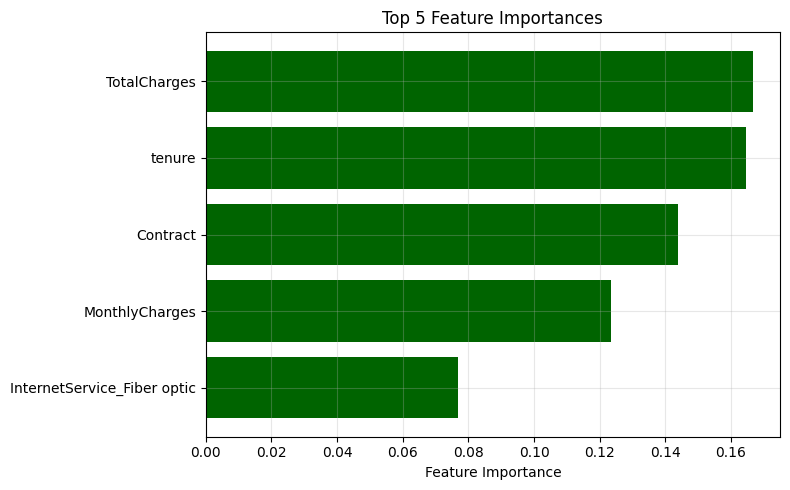

In [71]:
# Feature Importance
# Extract feature importances from RandomForest inside pipeline
rf_feature_importance = rf_pipeline.named_steps['classifier'].feature_importances_
try:
    raw_feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
    feature_names = [name.split('__')[-1] for name in raw_feature_names]
except:
    feature_names = [f"feature_{i}" for i in range(len(rf_feature_importance))]

top_n = 5
top_indices = np.argsort(rf_feature_importance)[-top_n:][::-1]  # Descending
top_features = [feature_names[i] for i in top_indices]
top_importance = rf_feature_importance[top_indices]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(top_n), top_importance, color='darkgreen')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features)
ax.invert_yaxis()  # Highest importance on top
ax.set_xlabel('Feature Importance')
ax.set_title(f'Top {top_n} Feature Importances')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Initital model evaluation summary:**
- XG Boost slightly outperforms Random Forest on test accuracy, ROC-AUC, and F-1 score.
- Both models perform similarly in terms of Recall (52%), indicating room for improvement.
- Train-test gap is larger in Random Forest, suggesting a bit more overfitting compared to XG Boost.

In [72]:
# # Feature Importance
# # Extract feature importances from RandomForest inside pipeline
# xgb_feature_importance = xgb_pipeline.named_steps['classifier'].feature_importances_
# try:
#     raw_feature_names = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()
#     feature_names = [name.split('__')[-1] for name in raw_feature_names]
# except:
#     feature_names = [f"feature_{i}" for i in range(len(xgb_feature_importance))]

# top_n = 5
# top_indices = np.argsort(xgb_feature_importance)[-top_n:][::-1]  # Descending
# top_features = [feature_names[i] for i in top_indices]
# top_importance = xgb_feature_importance[top_indices]

# fig, ax = plt.subplots(figsize=(8, 5))
# ax.barh(range(top_n), top_importance, color='darkgreen')
# ax.set_yticks(range(top_n))
# ax.set_yticklabels(top_features)
# ax.invert_yaxis()  # Highest importance on top
# ax.set_xlabel('Feature Importance')
# ax.set_title(f'Top {top_n} Feature Importances')
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

### Addressing Class Imbalance
**Expected Improvements:**
- Improve your F1 score by:
    * Increasing Recall: Better identification of actual churners (reducing false negatives)
    * Maintaining Precision: While not sacrificing too much accuracy in positive predictions
    * Better Balance: Finding the optimal trade-off between precision and recall

In [73]:
from collections import Counter

# Original class distribution
print("Training set:", Counter(y_train))
print("Test set:", Counter(y_test))
print(f"Imbalance ratio (majority/minority): {Counter(y_train)[0] / Counter(y_train)[1]:.2f}")

Training set: Counter({0: 4139, 1: 1495})
Test set: Counter({0: 1035, 1: 374})
Imbalance ratio (majority/minority): 2.77


##### Approach: Class Weights

In [74]:
# Compute class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced', 
    classes=np.unique(y_train), 
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Computed class weights: {class_weight_dict}")

Computed class weights: {0: 0.6805991785455424, 1: 1.8842809364548494}


In [75]:
# Random Forest with class weights
rf_weighted_pipeline = Pipeline([
    ('preprocessor', preprocessing_pipeline),
    ('debug', DebugTransformer(name_X = 'X_preprocessed', name_y='y_debug')),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=3,
        min_samples_leaf=2,
        class_weight=class_weight_dict,  # This automatically balances
        random_state=42,
        n_jobs=-1
    ))
])

# XGBoost with scale_pos_weight
pos_weight = Counter(y_train)[0] / Counter(y_train)[1]  # negative/positive ratio
xgb_weighted_pipeline = Pipeline([
    ('preprocessor', preprocessing_pipeline),
    ('debug', DebugTransformer(name_X = 'X_preprocessed', name_y='y_debug')),
    ('classifier', XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=pos_weight,  # XGBoost's way of handling imbalance
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        use_label_encoder=False
    ))
])

In [76]:
# ----- Train weighted models -----
print("Training Random Forest with balanced class weights...")
rf_weighted_pipeline.fit(X_train, y_train)
print("\nTraining XGBoost with scale_pos_weight...")
xgb_weighted_pipeline.fit(X_train, y_train)

# ----- Evaluate weighted models -----
rf_weighted_results = evaluate_model(rf_weighted_pipeline, X_train, X_test, y_train, y_test)
xgb_weighted_results = evaluate_model(xgb_weighted_pipeline, X_train, X_test, y_train, y_test)

Training Random Forest with balanced class weights...

Training XGBoost with scale_pos_weight...

RandomForestClassifier SUMMARY
Train accuracy:0.7529286474973376 | Test accuracy=0.7395315826827538 | Test ROC_AUC:0.8415730191945026

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

=== Confusion Matrix ===
     0    1
0  741  294
1   73  301

XGBClassifier SUMMARY
Train accuracy:0.7703230386936457 | Test accuracy=0.7437899219304471 | Test ROC_AUC:0.8469516133198998

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                

**Weighted model evaluation summary:**
- **XGBoost continues to outperform Random Forest** in overall performance with slightly higher test accuracy and ROC AUC, indicating better discrimination between churn vs non-churn.
- **Random Forest has a marginally higher recall**, meaning it captured slightly more churners
- **Both models have low precision** (~51%), suggesting that about half of the predicted churners are actually not churners — this is common in imbalanced datasets.
- F1-score are identical.

**Summary of Analysis & Next Steps:**

Our goal is to maximize Recall, F1, Precision, and ROC AUC in this churn prediction problem, we are essentially aiming for a balanced, high-performing model — not just catching churners, but doing it confidently and accurately.

To build a more confident and accurate churn detection system:
- We need to tune the model (Hyperparameter Optimization)


### Model Tuning